
REST API 


# Описание

| Эндпоинт | Метод | Описание |
|---|---|---|
| `/api/posts` | GET | Список всех постов с пагинацией и фильтрацией |
| `/api/posts/<id>` | GET | Конкретный пост по ID |
| `/api/posts` | POST | Создание нового поста |
| `/api/posts/<id>` | PUT | Обновление поста |
| `/api/posts/<id>` | DELETE | Удаление поста |
| `/api/docs` | GET | Документация API |

- **Аутентификация** через API-ключ (заголовок `X-API-Key` или параметр `?api_key=`)
- **Обработка ошибок** с правильными HTTP-кодами: 400, 401, 404, 422, 500

### Индивидуальные особенности

**1. Пагинация** — главная страница и API поддерживают разбивку на страницы по 5 постов. Параметр `?page=N` работает как в веб-интерфейсе, так и в API.

**2. Экспорт в CSV** — маршрут `/export/csv` формирует файл `posts_export.csv` со всеми постами и отдаёт его браузеру для скачивания.
```

# Структура базы данных

## SQL-схема

In [ ]:
schema_sql = """
DROP TABLE IF EXISTS posts;

CREATE TABLE posts (
    id      INTEGER PRIMARY KEY AUTOINCREMENT,
    created TIMESTAMP NOT NULL DEFAULT CURRENT_TIMESTAMP,
    title   TEXT NOT NULL,
    content TEXT NOT NULL
);
"""
print(schema_sql)

## Описание полей таблицы `posts`

| Поле | Тип | Ограничение | Описание |
|---|---|---|---|
| `id` | INTEGER | PRIMARY KEY, AUTOINCREMENT | Уникальный идентификатор, увеличивается автоматически |
| `created` | TIMESTAMP | NOT NULL, DEFAULT CURRENT_TIMESTAMP | Дата и время создания, устанавливается автоматически |
| `title` | TEXT | NOT NULL | Заголовок поста, обязательное поле |
| `content` | TEXT | NOT NULL | Текстовое содержание, обязательное поле |

## Диаграмма

```
┌─────────────────────────┐
│          posts           │
├──────────┬──────────────┤
│ id       │ INTEGER  PK  │
│ created  │ TIMESTAMP    │
│ title    │ TEXT         │
│ content  │ TEXT         │
└──────────┴──────────────┘
```

Одна таблица `posts`, внешних ключей нет — минималистичная архитектура блога без системы пользователей.

# Ключевые фрагменты кода

## Декоратор аутентификации по API-ключу

In [ ]:
from functools import wraps
from flask import request, jsonify

API_KEY = 'demo-api-key-12345'

def require_api_key(f):
    """
    Декоратор: проверяет наличие корректного API-ключа
    в заголовке X-API-Key или параметре запроса ?api_key=.
    Возвращает 401 Unauthorized при неверном ключе.
    """
    @wraps(f)
    def decorated(*args, **kwargs):
        key = request.headers.get('X-API-Key') or request.args.get('api_key')
        if key != API_KEY:
            return jsonify({'error': 'Unauthorized. Provide a valid API key.'}), 401
        return f(*args, **kwargs)
    return decorated

Декоратор применяется ко всем пяти API-маршрутам через `@require_api_key`. Ключ принимается двумя способами: через HTTP-заголовок (рекомендуется) или через GET-параметр (удобно для тестирования в браузере).

---

## GET /api/posts — список постов

In [ ]:
@app.route('/api/posts', methods=['GET'])
@require_api_key
def api_get_posts():
    """
    GET /api/posts — список постов с пагинацией, поиском и сортировкой.
    Параметры: page, per_page (макс. 50), sort (asc/desc), q (поиск)
    """
    page     = max(1, request.args.get('page', 1, type=int))
    per_page = min(50, max(1, request.args.get('per_page', 5, type=int)))
    sort     = request.args.get('sort', 'desc').lower()
    q        = request.args.get('q', '').strip()

    if sort not in ('asc', 'desc'):
        sort = 'desc'   # защита от некорректного значения

    order  = f'created {sort.upper()}'
    offset = (page - 1) * per_page
    conn   = get_db_connection()

    if q:
        total = conn.execute(
            'SELECT COUNT(*) FROM posts WHERE title LIKE ? OR content LIKE ?',
            (f'%{q}%', f'%{q}%')
        ).fetchone()[0]
        rows = conn.execute(
            f'SELECT * FROM posts WHERE title LIKE ? OR content LIKE ?'
            f' ORDER BY {order} LIMIT ? OFFSET ?',
            (f'%{q}%', f'%{q}%', per_page, offset)
        ).fetchall()
    else:
        total = conn.execute('SELECT COUNT(*) FROM posts').fetchone()[0]
        rows  = conn.execute(
            f'SELECT * FROM posts ORDER BY {order} LIMIT ? OFFSET ?',
            (per_page, offset)
        ).fetchall()

    conn.close()
    total_pages = (total + per_page - 1) // per_page

    return jsonify({
        'posts': [dict(r) for r in rows],
        'pagination': {
            'page': page, 'per_page': per_page,
            'total': total, 'total_pages': total_pages,
            'has_next': page < total_pages,
            'has_prev': page > 1,
        }
    }), 200

---

## GET /api/posts/\<id\> — конкретный пост

In [ ]:
@app.route('/api/posts/<int:post_id>', methods=['GET'])
@require_api_key
def api_get_post(post_id):
    """GET /api/posts/<id> — возвращает один пост по ID."""
    conn = get_db_connection()
    row  = conn.execute('SELECT * FROM posts WHERE id = ?', (post_id,)).fetchone()
    conn.close()

    if row is None:
        return jsonify({'error': f'Post {post_id} not found.'}), 404

    return jsonify(dict(row)), 200

---

## POST /api/posts — создание поста с валидацией

In [ ]:
@app.route('/api/posts', methods=['POST'])
@require_api_key
def api_create_post():
    """
    POST /api/posts — создание поста.
    Тело: JSON { "title": "...", "content": "..." }
    Возвращает созданный пост с кодом 201 Created.
    """
    data = request.get_json(silent=True)   # silent=True — не падает на невалидном JSON
    if not data:
        return jsonify({'error': 'Invalid or missing JSON body.'}), 400

    title   = data.get('title',   '').strip()
    content = data.get('content', '').strip()

    if not title:
        return jsonify({'error': 'Field "title" is required.'}), 422
    if not content:
        return jsonify({'error': 'Field "content" is required.'}), 422

    conn = get_db_connection()
    cur  = conn.execute(
        'INSERT INTO posts (title, content) VALUES (?, ?)', (title, content)
    )
    conn.commit()
    row = conn.execute('SELECT * FROM posts WHERE id = ?', (cur.lastrowid,)).fetchone()
    conn.close()

    return jsonify(dict(row)), 201

---

## PUT /api/posts/\<id\> — обновление поста

In [ ]:
@app.route('/api/posts/<int:post_id>', methods=['PUT'])
@require_api_key
def api_update_post(post_id):
    """
    PUT /api/posts/<id> — обновление поста.
    Тело: JSON { "title": "...", "content": "..." }
    Можно передать только одно поле — второе сохранится без изменений.
    """
    conn = get_db_connection()
    row  = conn.execute('SELECT * FROM posts WHERE id = ?', (post_id,)).fetchone()
    if row is None:
        conn.close()
        return jsonify({'error': f'Post {post_id} not found.'}), 404

    data = request.get_json(silent=True)
    if not data:
        conn.close()
        return jsonify({'error': 'Invalid or missing JSON body.'}), 400

    # Если поле не передано — берём старое значение из БД (частичное обновление)
    title   = data.get('title',   row['title']).strip()
    content = data.get('content', row['content']).strip()

    if not title:
        conn.close()
        return jsonify({'error': 'Field "title" cannot be empty.'}), 422

    conn.execute(
        'UPDATE posts SET title = ?, content = ? WHERE id = ?',
        (title, content, post_id)
    )
    conn.commit()
    updated = conn.execute('SELECT * FROM posts WHERE id = ?', (post_id,)).fetchone()
    conn.close()

    return jsonify(dict(updated)), 200

---

## DELETE /api/posts/\<id\> — удаление поста

In [ ]:
@app.route('/api/posts/<int:post_id>', methods=['DELETE'])
@require_api_key
def api_delete_post(post_id):
    """DELETE /api/posts/<id> — безвозвратно удаляет пост."""
    conn = get_db_connection()
    row  = conn.execute('SELECT * FROM posts WHERE id = ?', (post_id,)).fetchone()
    if row is None:
        conn.close()
        return jsonify({'error': f'Post {post_id} not found.'}), 404

    conn.execute('DELETE FROM posts WHERE id = ?', (post_id,))
    conn.commit()
    conn.close()

    return jsonify({'message': f'Post {post_id} deleted successfully.'}), 200

---

## GET /api/docs — страница документации

In [ ]:
@app.route('/api/docs')
def api_docs():
    """
    GET /api/docs — публичная HTML-страница с документацией REST API.
    Аутентификация не требуется.
    Передаёт api_key в шаблон для отображения в примерах curl-команд.
    """
    return render_template('api_docs.html', api_key=API_KEY)

---

## Обработчики ошибок

In [ ]:
@app.errorhandler(404)
def not_found(e):
    """Для API — JSON, для веб — HTML-шаблон."""
    if request.path.startswith('/api/'):
        return jsonify({'error': 'Not found.'}), 404
    return render_template('404.html'), 404

@app.errorhandler(405)
def method_not_allowed(e):
    if request.path.startswith('/api/'):
        return jsonify({'error': 'Method not allowed.'}), 405
    return render_template('404.html'), 405

@app.errorhandler(500)
def internal_error(e):
    if request.path.startswith('/api/'):
        return jsonify({'error': 'Internal server error.'}), 500
    return render_template('404.html'), 500

# Проблемы и их решение

## Проблема 1: SQL-инъекция при динамической сортировке

**Описание:** Параметр `sort` подставлялся в SQL напрямую. Параметризованные запросы не поддерживают ключевые слова ORDER BY, поэтому `?` здесь неприменим.

**Решение:** Белый список допустимых значений:
```python
sort = request.args.get('sort', 'desc').lower()
if sort not in ('asc', 'desc'):
    sort = 'desc'  # сброс к безопасному значению
order = f'created {sort.upper()}'
```

---

## Проблема 2: Пагинация сбрасывала поисковый запрос

**Описание:** При переходе на следующую страницу параметр `?q=` терялся из URL.

**Решение:** Параметр `q` явно передаётся в `url_for()` во всех ссылках пагинации:
```html
<a class="page-link" href="{{ url_for('index', page=p, q=q) }}">{{ p }}</a>
```

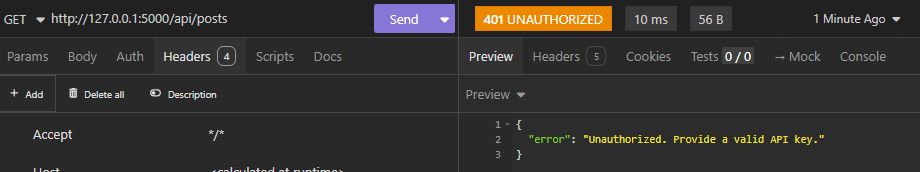
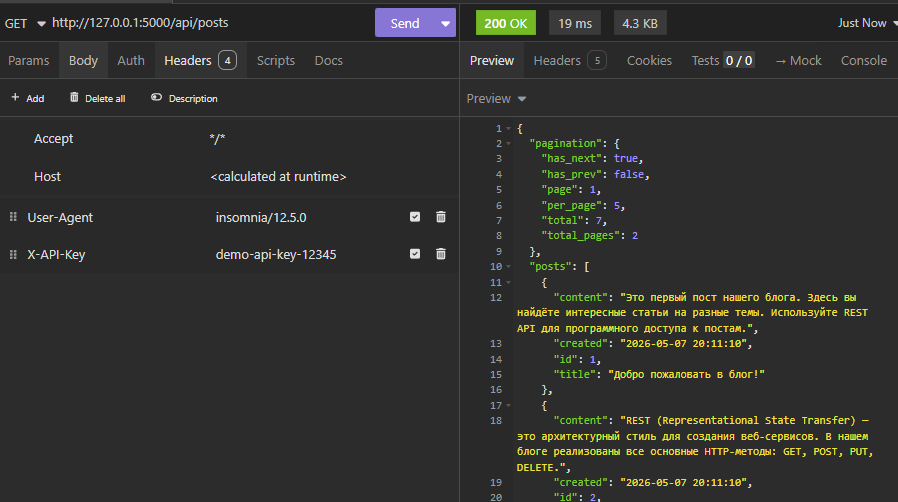
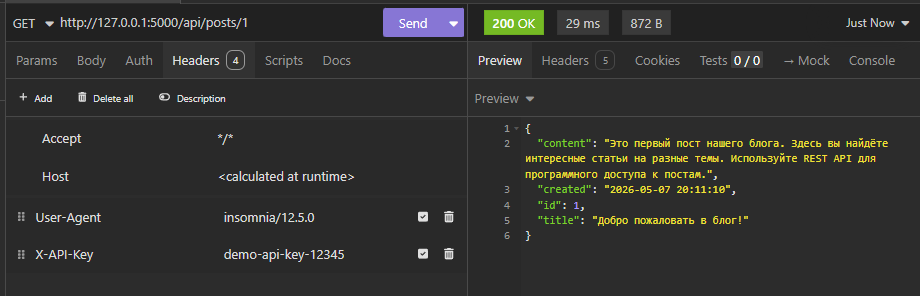
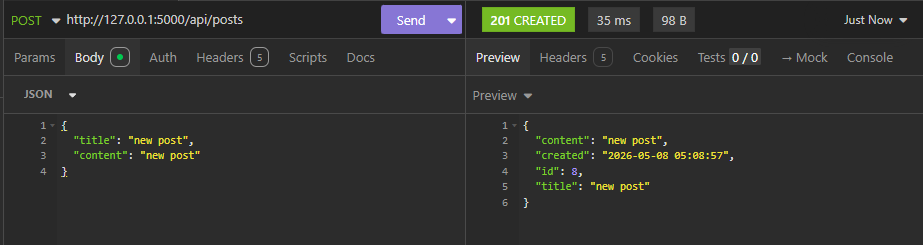
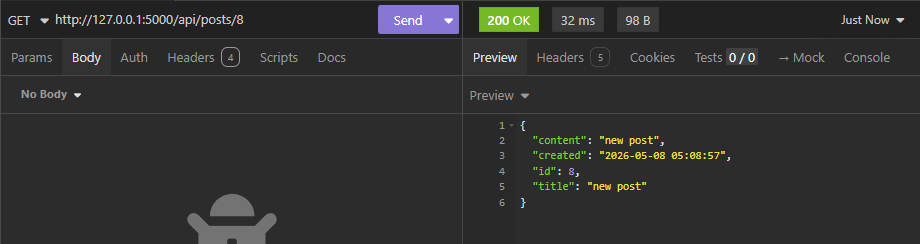
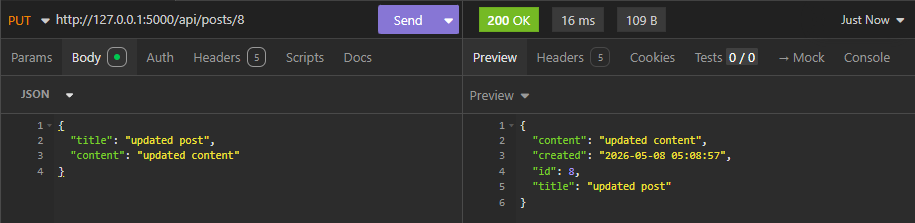
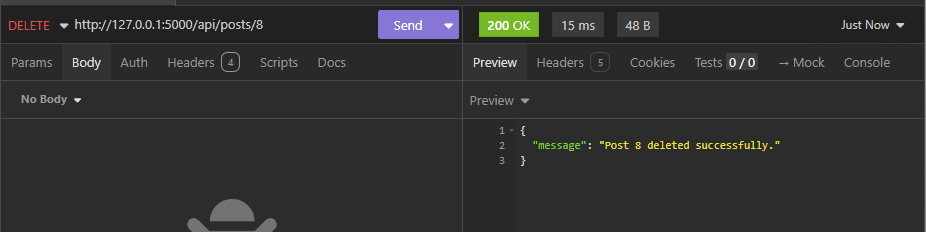
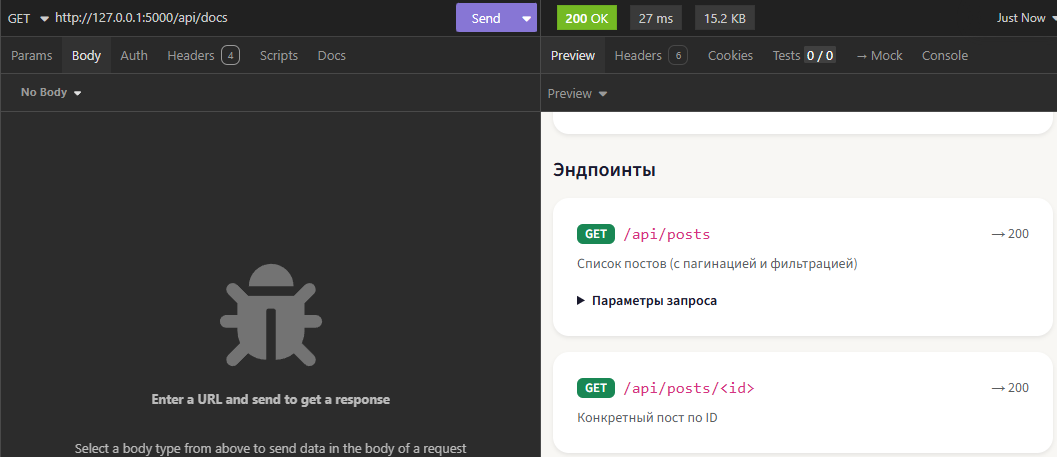